<a href="https://colab.research.google.com/github/RGarancs/applied-ai-academy-labs/blob/main/solutions/dundermifflin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dunder Mifflin — retail orders (case study)

**Applied AI Academy — problem set with worked answers**

**Used in:** Lesson 26 — Retail AI wins at the shelf edge: demand, price, and the next best offer  
**Rows:** 9,994  ·  **Source file:** `dunder_mifflin_orders.csv`



---
### How to use this notebook
Run the cells in order. Each problem is stated first, then solved, then the
answer is spelled out. For teaching, hide the solution cells and let the room
attempt the task before revealing them.

> The data loads straight from `appliedai.center` — nothing to upload.


## Setup

In [1]:
%matplotlib inline
import pandas as pd, numpy as np, os, urllib.request
import matplotlib, matplotlib.pyplot as plt
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

# Applied AI Academy chart style — calm, legible when projected
INK, ACCENT, CORE, BUILDER, DANGER = "#26214a", "#544d94", "#5b8a6e", "#a8845c", "#b05a5a"
matplotlib.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c9c4d8", "axes.labelcolor": INK, "axes.titlesize": 13,
    "axes.titleweight": "600", "axes.titlecolor": INK, "axes.titlepad": 14,
    "text.color": INK, "xtick.color": INK, "ytick.color": INK,
    "font.size": 10, "grid.color": "#e6e2ef", "axes.grid": True,
    "axes.axisbelow": True, "grid.linewidth": .8, "figure.facecolor": "white",
})

URL   = "https://appliedai.center/assets/datasets/dunder_mifflin_orders.csv"
LOCAL = "dunder_mifflin_orders.csv"
if not os.path.exists(LOCAL):
    print("Downloading", URL)
    urllib.request.urlretrieve(URL, LOCAL)

df = pd.read_csv(LOCAL, low_memory=False)
print("Shape:", df.shape)
df.head()

Shape: (9994, 22)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Returned
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,No
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,No
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,No
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,No
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,No


## What is in the file

In [2]:
print("Columns and types:")
print(df.dtypes.to_string())
miss = df.isna().sum()
miss = miss[miss > 0]
print("\nMissing values:" if len(miss) else "\nNo missing values.")
if len(miss): print(miss.to_string())

Columns and types:
Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code      float64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
Returned             str

Missing values:
Postal Code    11


---
## Problem 1 · Easy — describe

Size the business: sales, profit and margin.

*Try it yourself first. The worked solution is below.*

In [3]:
print(f"Orders: {df['Order ID'].nunique():,}   Rows: {len(df):,}")
print(f"Sales:  EUR {df['Sales'].sum():,.0f}")
print(f"Profit: EUR {df['Profit'].sum():,.0f}")
print(f"Margin: {df['Profit'].sum()/df['Sales'].sum():.1%}")
print("\nBy category:")
print(df.groupby("Category").agg(sales=("Sales","sum"), profit=("Profit","sum"))
        .assign(margin=lambda d: (d.profit/d.sales*100).round(1)).round(0))

Orders: 5,009   Rows: 9,994
Sales:  EUR 3,003,514
Profit: EUR 286,397
Margin: 9.5%

By category:
                     sales    profit  margin
Category                                    
Furniture         742000.0   18451.0     2.0
Office Supplies  1425360.0  122491.0     9.0
Technology        836154.0  145455.0    17.0


---
## Problem 2 · Intermediate — build

Find what loses money — and be specific about it.

*Try it yourself first. The worked solution is below.*

In [4]:
sub = (df.groupby("Sub-Category").agg(sales=("Sales","sum"), profit=("Profit","sum"))
         .assign(margin=lambda d: (d.profit/d.sales*100).round(1))
         .sort_values("profit"))
print("Worst sub-categories by profit:\n", sub.head(6).round(0))
print("\nBest:\n", sub.tail(4).round(0))
print("\nProfit by region:")
print(df.groupby("Region").agg(sales=("Sales","sum"), profit=("Profit","sum")).round(0))

Worst sub-categories by profit:
                  sales   profit  margin
Sub-Category                           
Tables        206966.0 -17725.0    -9.0
Bookcases     114880.0  -3473.0    -3.0
Supplies       46674.0  -1189.0    -2.0
Fasteners       3024.0    950.0    31.0
Machines      189239.0   3385.0     2.0
Labels         12486.0   5546.0    44.0

Best:
                  sales   profit  margin
Sub-Category                           
Paper         784792.0  34054.0     4.0
Accessories   167380.0  41937.0    25.0
Phones        330007.0  44516.0    14.0
Copiers       149528.0  55618.0    37.0

Profit by region:
            sales    profit
Region                     
Central  658667.0   39706.0
East     860335.0   91523.0
South    519081.0   46749.0
West     965431.0  108418.0


---
## Problem 3 · Advanced — judge

Show the discount cliff — the actionable finding.

*Try it yourself first. The worked solution is below.*

In [5]:
band = pd.cut(df["Discount"], [-0.001,0,.1,.2,.3,.4,1],
              labels=["0%","1-10%","11-20%","21-30%","31-40%","40%+"])
d = (df.groupby(band, observed=True)
       .agg(orders=("Sales","size"), sales=("Sales","sum"), profit=("Profit","sum"))
       .assign(margin=lambda x: (x.profit/x.sales*100).round(1)))
print(d.round(0))
neg = d[d["profit"] < 0]
if len(neg):
    print(f"\nProfit turns NEGATIVE from the '{neg.index[0]}' band onwards.")
print("\nThat is a pricing rule you can hand to sales on Monday.")

          orders      sales    profit  margin
Discount                                     
0%          4798  1566329.0  320988.0    20.0
1-10%         94    54369.0    9029.0    17.0
11-20%      3709  1020045.0   91756.0     9.0
21-30%       227   103227.0  -10369.0   -10.0
31-40%       233   130911.0  -25448.0   -19.0
40%+         933   128632.0  -99559.0   -77.0

Profit turns NEGATIVE from the '21-30%' band onwards.

That is a pricing rule you can hand to sales on Monday.


---
## Visual summary

The same answers, as pictures. These are what to project — a room reads a chart
far faster than it reads a table, and the shape of a result is usually the
argument you are actually making.

findfont: Failed to find font weight 600, now using 700.


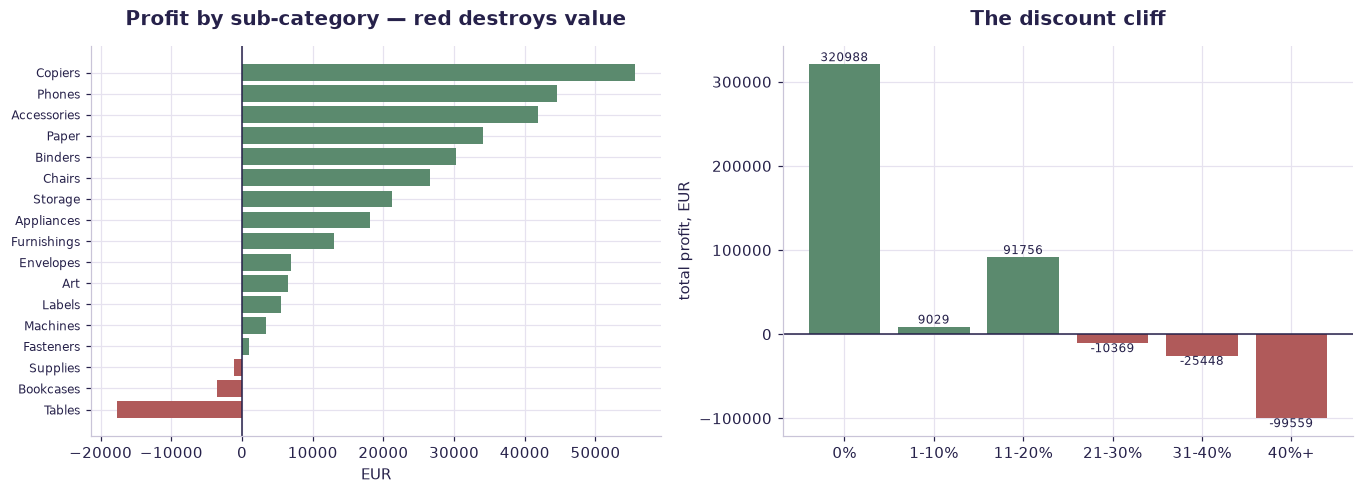

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.6))
sub = df.groupby("Sub-Category")["Profit"].sum().sort_values()
cols = [DANGER if v < 0 else CORE for v in sub.values]
ax[0].barh(sub.index, sub.values, color=cols)
ax[0].axvline(0, color=INK, lw=1)
ax[0].set_title("Profit by sub-category — red destroys value"); ax[0].set_xlabel("EUR")
ax[0].tick_params(axis="y", labelsize=8)

band = pd.cut(df["Discount"], [-.001,0,.1,.2,.3,.4,1], labels=["0%","1-10%","11-20%","21-30%","31-40%","40%+"])
d = df.groupby(band, observed=True)["Profit"].sum()
cols = [CORE if v > 0 else DANGER for v in d.values]
b = ax[1].bar(d.index.astype(str), d.values, color=cols)
ax[1].axhline(0, color=INK, lw=1)
ax[1].set_title("The discount cliff"); ax[1].set_ylabel("total profit, EUR")
ax[1].bar_label(b, fmt="%.0f", fontsize=8)
plt.tight_layout(); plt.show()

---
## Verified answer key

These are the numbers the academy ships for this dataset. They were computed
from this exact file — if your run disagrees, reconcile before teaching it.

1. Total sales $3.00M · profit $286k · blended margin 9.5%
2. Technology margin 17.4% vs Furniture just 2.5% — mix matters
3. Tables LOSE $17.7k and Bookcases −$3.5k; Copiers (+$55.6k) & Phones (+$44.5k) carry the book
4. Discounts are the leak: avg profit +$66.90 at 0% discount vs −$97.18 at ≥30% discount
5. Return rate ~8.0% of line items — factor it into "profit"


---
## Teaching notes

* **Run the Easy problem live.** It sets the shared vocabulary and gets everyone
  looking at the same rows.
* **Let them fail on the Intermediate one.** The productive mistake is usually
  reaching for a model before checking the data.
* **Argue about the Advanced one.** It has no single right answer; it has a
  defensible one, and defending it is the skill being taught.
* **Always close on limitations.** Every dataset here has a real caveat —
  scrape bias, a tiny sample, a hindsight label. Naming it is the lesson.
* **Deliverable for learners:** The retail AI playbook one-pager (Core: the value-chain diagnosis).

---
*Applied AI Academy · appliedai.center*
